In [1]:
from dinosaw.models.lightning_model import PEModel
from dinosaw.utils import normalize, load_image, resize_crop, do_2D_pca, closest_crop
import torch
import matplotlib.pyplot as plt
from dinosaw.models.vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_LIST,
)

from dinosaw.utils import get_ramp, gen_sample_mask, linear_probe, probe

/home/ab_aimd_anja_20884/anaconda3/envs/moritz_eng_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=False, device="cuda").eval().half()
model = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/dinosaw/trained_models/test-epoch=67-val_loss=0.18.ckpt").half()

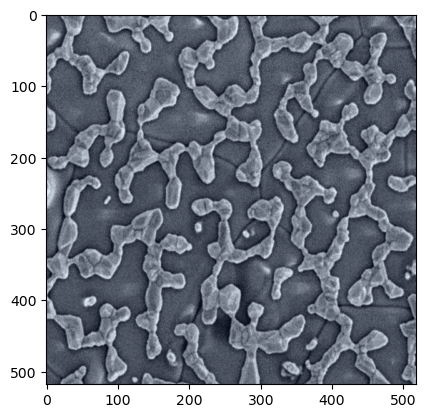

In [3]:
img_size=1*518
test_img = load_image("images/default_image.jpg", resize_crop((img_size, img_size), (img_size, img_size)))[0]
plt.imshow(normalize(test_img.cpu().squeeze().permute(1,2,0).float()))

In [ ]:
res = vit_wrapper.forward_features(test_img, make_2D=True)
#res = model(test_img)
res.shape

torch.Size([1, 384, 37, 37])

In [47]:
res_np = res.squeeze().detach().cpu().numpy()
c,h,w = res.squeeze().shape
sample_mask = gen_sample_mask((h, w), step=3, cutoff_frac=0.8)
ramp = get_ramp("lr", h=h, w=w)

In [ ]:
%%capture
scores=[]
fig, axes = plt.subplots(20,20, dpi=300, figsize=(50,50))
for ax, idx in zip(axes.ravel(), range(384)):
    data, score = linear_probe(res_np[idx:idx+1,...], ramp, sample_mask)
    scores.append(score)
    ax.imshow(data)
    ax.set_title(f"(R²: {score:.3f})")
#fig.savefig("channel_probe_our.png")

## only the Scores

In [4]:
res_DINO = vit_wrapper.forward_features(test_img, make_2D=True)
res_our = model(test_img)
res_DINO.shape, res_our.shape

(torch.Size([1, 384, 37, 37]), torch.Size([1, 384, 37, 37]))

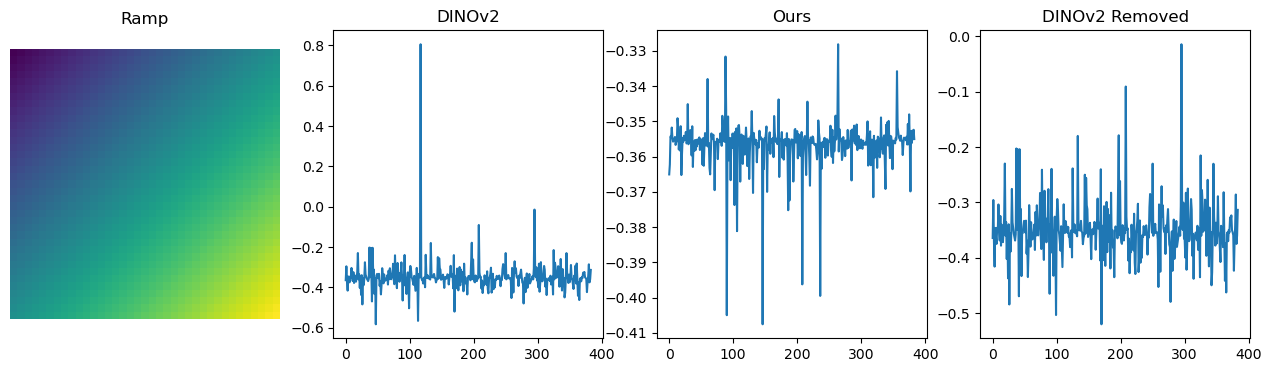

In [20]:
probe([res_DINO, res_our, res_DINO], [False, False, True], ["DINOv2", "Ours", "DINOv2 Removed"], ramp="diag", by_channel=True, mask_step=3)